# Load


In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import csv
import cartopy.crs as ccrs
from shapely.geometry import Point
from shapely.geometry import LineString
import shapely.wkt
import movingpandas as mpd
from shapely.geometry import Point
from datetime import timedelta
import trackintel as ti
import glob

c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\movingpandas\__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)


In [17]:
Wikiloc_trajectories = gpd.read_file("Data/Wikiloc/Trajectories/Trajectories.gpkg")
# Alltrail_counts = gpd.read_file("Data/Alltrails/tracks_with_activity_counts.gpkg")
Alltrail_activities = pd.read_csv("Data/Alltrails/Downloads/activity_index.csv")
Counter_Locations = gpd.read_file("Data/DOC_Counter_Locations.gpkg")
Counter_data = pd.read_csv("Data/DOC_Counter_Data_2022.csv")
mobile = gpd.read_file("Data/Final_Matched_Filtered.gpkg")

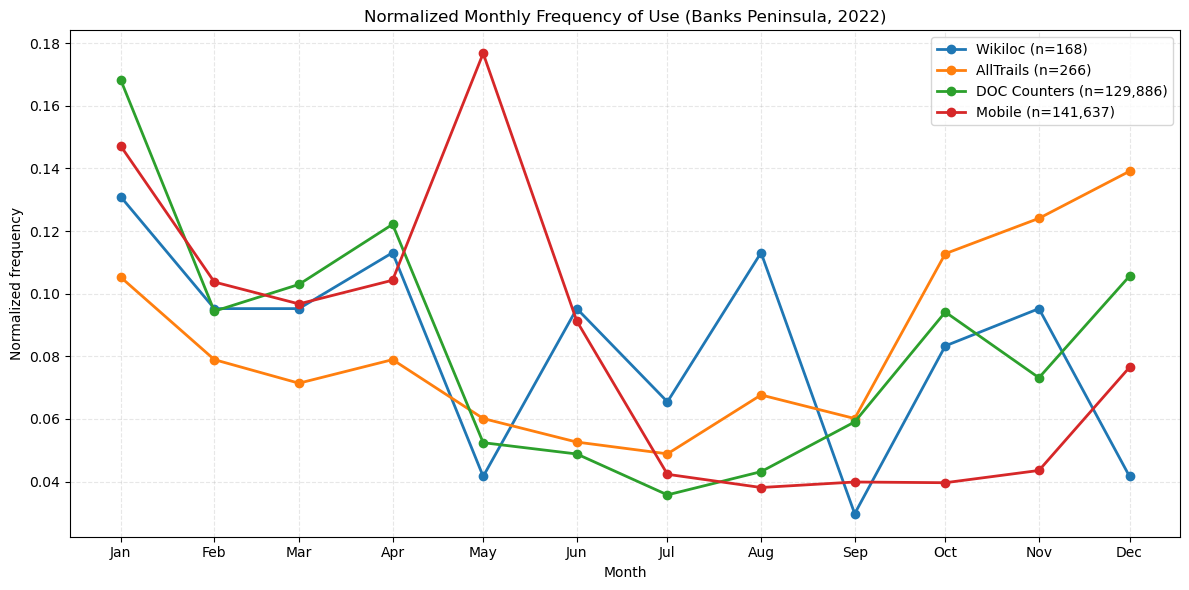

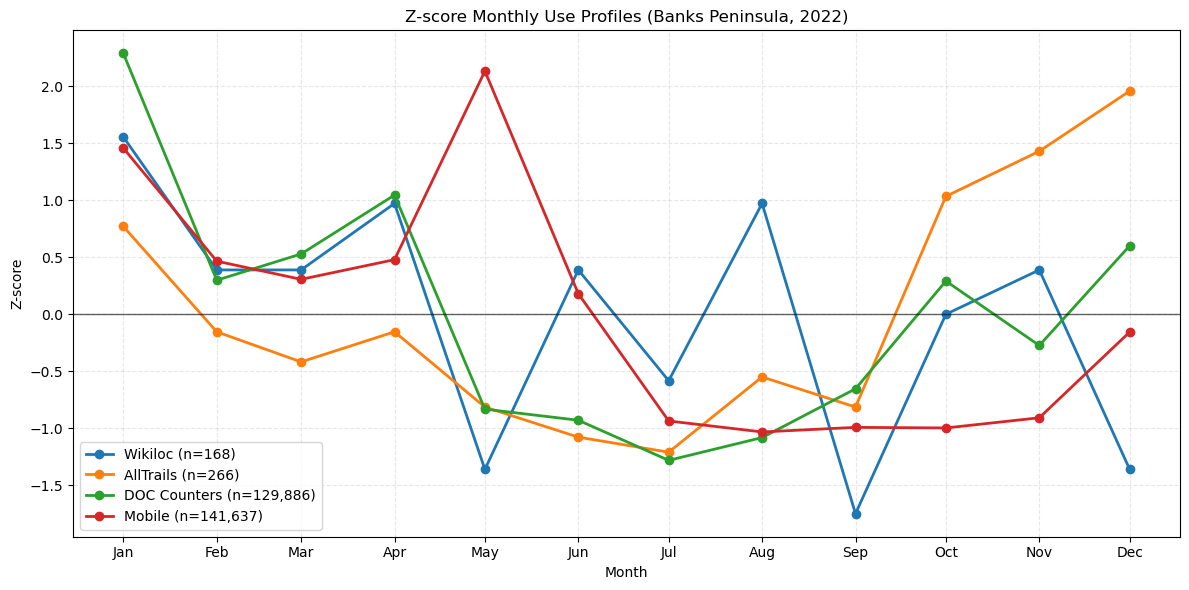

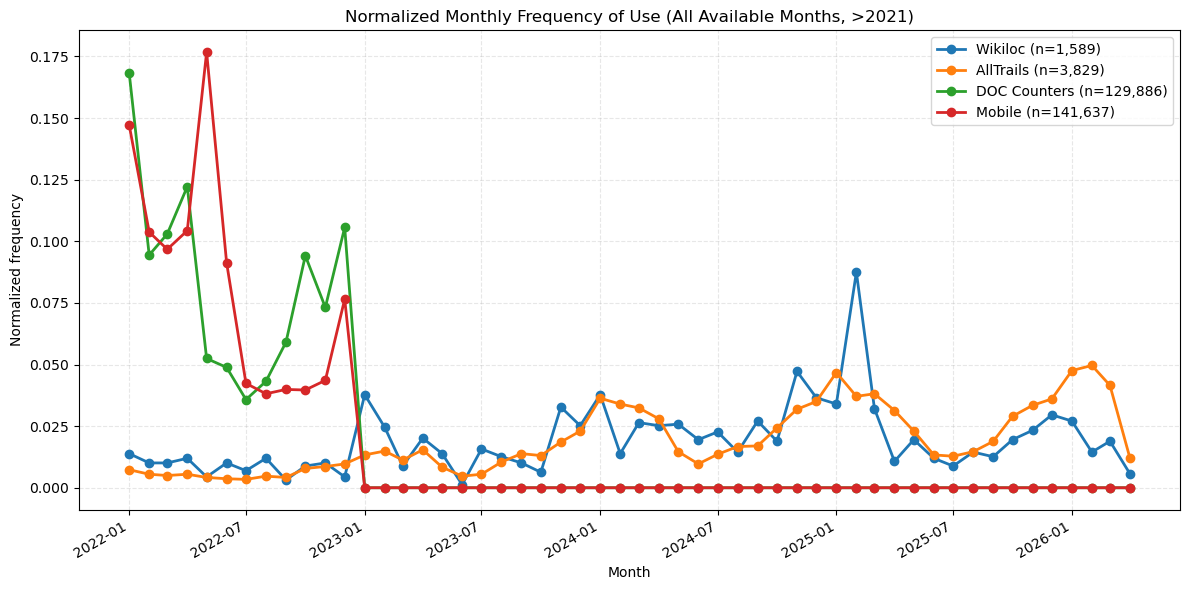

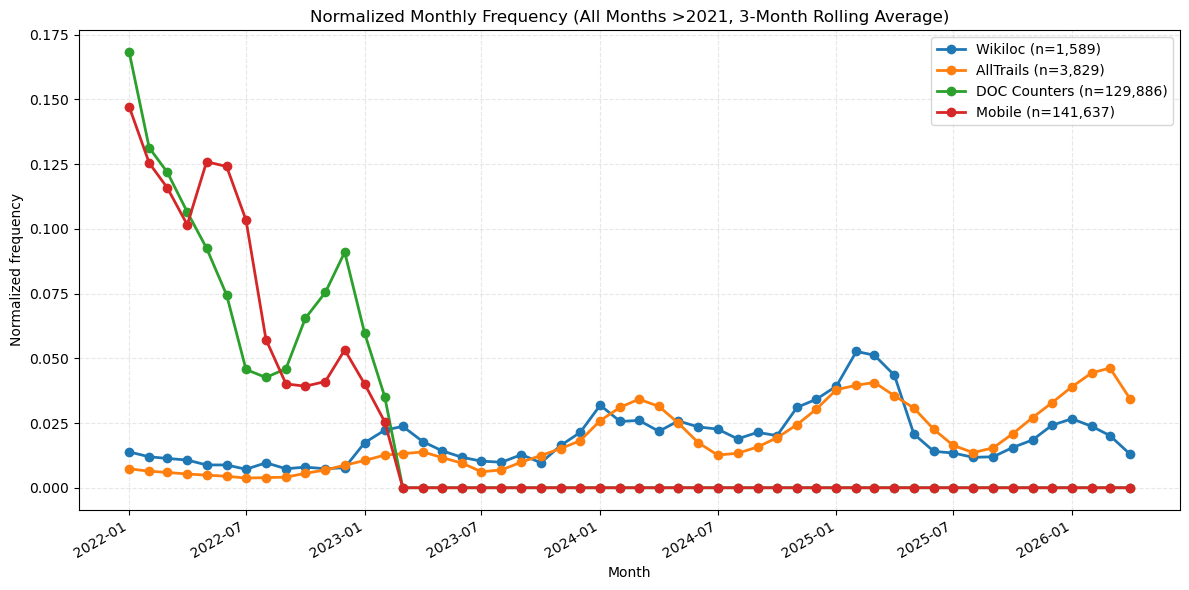

In [18]:
# Ensure required datasets are available
if "Wikiloc_trajectories" not in globals():
    Wikiloc_trajectories = gpd.read_file("Data/Wikiloc/Trajectories/Trajectories.gpkg")
if "Alltrail_activities" not in globals():
    Alltrail_activities = pd.read_csv("Data/Alltrails/Downloads/activity_index.csv")
if "Counter_data" not in globals():
    Counter_data = pd.read_csv("Data/DOC_Counter_Data_2022.csv")
if "mobile" not in globals():
    mobile = gpd.read_file("Data/Final_Matched_Filtered.gpkg")

# Build a monthly index for 2022
months_2022 = pd.date_range("2022-01-01", "2022-12-01", freq="MS")

# Parse and clean dates
wikiloc_dates = pd.to_datetime(Wikiloc_trajectories["start_time"], errors="coerce")
alltrails_dates = pd.to_datetime(Alltrail_activities["activity_date"], errors="coerce", dayfirst=True)
counter_dates = pd.to_datetime(Counter_data["Datetime"], errors="coerce")
mobile_dates = pd.to_datetime(mobile["middle_time"], errors="coerce", utc=True).dt.tz_localize(None)

# Remove implausible historical timestamps that come from parser/source artifacts
wikiloc_dates = wikiloc_dates[wikiloc_dates.dt.year >= 2000]
alltrails_dates = alltrails_dates[alltrails_dates.dt.year >= 2000]
counter_dates = counter_dates[counter_dates.dt.year >= 2000]
mobile_dates = mobile_dates[mobile_dates.dt.year >= 2000]

# Wikiloc: count trajectories by start month
wikiloc_monthly = (
    pd.Series(1, index=wikiloc_dates)
    .groupby(pd.Grouper(freq="MS"))
    .sum()
    .reindex(months_2022, fill_value=0)
)

# AllTrails: count activities by activity_date month
alltrails_monthly = (
    pd.Series(1, index=alltrails_dates)
    .groupby(pd.Grouper(freq="MS"))
    .sum()
    .reindex(months_2022, fill_value=0)
)

# DOC counters: sum hourly counts into monthly totals
doc_monthly = (
    Counter_data.assign(Datetime=counter_dates)
    .dropna(subset=["Datetime"])
    .set_index("Datetime")["Count"]
    .groupby(pd.Grouper(freq="MS"))
    .sum()
    .reindex(months_2022, fill_value=0)
)

# Mobile: count matched trips by middle_time month
mobile_monthly = (
    pd.Series(1, index=mobile_dates)
    .groupby(pd.Grouper(freq="MS"))
    .sum()
    .reindex(months_2022, fill_value=0)
)

# Normalize each source to relative monthly frequency (sum of each line = 1)
def normalize_series(series):
    total = series.sum()
    return series / total if total > 0 else series

# Standardize each source to z-scores for seasonal shape comparison
def zscore_series(series):
    std = series.std(ddof=0)
    if std == 0 or pd.isna(std):
        return pd.Series(0, index=series.index)
    return (series - series.mean()) / std

wikiloc_norm = normalize_series(wikiloc_monthly)
alltrails_norm = normalize_series(alltrails_monthly)
doc_norm = normalize_series(doc_monthly)
mobile_norm = normalize_series(mobile_monthly)

wikiloc_z = zscore_series(wikiloc_monthly)
alltrails_z = zscore_series(alltrails_monthly)
doc_z = zscore_series(doc_monthly)
mobile_z = zscore_series(mobile_monthly)

wikiloc_total = int(wikiloc_monthly.sum())
alltrails_total = int(alltrails_monthly.sum())
doc_total = int(doc_monthly.sum())
mobile_total = int(mobile_monthly.sum())

# Plot 1: overlayed monthly normalized frequencies with totals in legend (2022)
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(months_2022, wikiloc_norm.values, marker="o", linewidth=2, label=f"Wikiloc (n={wikiloc_total:,})")
ax.plot(months_2022, alltrails_norm.values, marker="o", linewidth=2, label=f"AllTrails (n={alltrails_total:,})")
ax.plot(months_2022, doc_norm.values, marker="o", linewidth=2, label=f"DOC Counters (n={doc_total:,})")
ax.plot(months_2022, mobile_norm.values, marker="o", linewidth=2, label=f"Mobile (n={mobile_total:,})")

ax.set_title("Normalized Monthly Frequency of Use (Banks Peninsula, 2022)")
ax.set_xlabel("Month")
ax.set_ylabel("Normalized frequency")
ax.set_xticks(months_2022)
ax.set_xticklabels([d.strftime("%b") for d in months_2022])
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2: overlayed z-score monthly profiles (2022)
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(months_2022, wikiloc_z.values, marker="o", linewidth=2, label=f"Wikiloc (n={wikiloc_total:,})")
ax.plot(months_2022, alltrails_z.values, marker="o", linewidth=2, label=f"AllTrails (n={alltrails_total:,})")
ax.plot(months_2022, doc_z.values, marker="o", linewidth=2, label=f"DOC Counters (n={doc_total:,})")
ax.plot(months_2022, mobile_z.values, marker="o", linewidth=2, label=f"Mobile (n={mobile_total:,})")

ax.axhline(0, color="black", linewidth=1, alpha=0.6)
ax.set_title("Z-score Monthly Use Profiles (Banks Peninsula, 2022)")
ax.set_xlabel("Month")
ax.set_ylabel("Z-score")
ax.set_xticks(months_2022)
ax.set_xticklabels([d.strftime("%b") for d in months_2022])
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# -------- Additional set: no 2022 filter (restricted to >2021) --------
wikiloc_monthly_all = pd.Series(1, index=wikiloc_dates).groupby(pd.Grouper(freq="MS")).sum()
alltrails_monthly_all = pd.Series(1, index=alltrails_dates).groupby(pd.Grouper(freq="MS")).sum()
doc_monthly_all = (
    Counter_data.assign(Datetime=counter_dates)
    .dropna(subset=["Datetime"])
    .set_index("Datetime")["Count"]
    .groupby(pd.Grouper(freq="MS"))
    .sum()
)
mobile_monthly_all = pd.Series(1, index=mobile_dates).groupby(pd.Grouper(freq="MS")).sum()

# Restrict non-combined monthly plots to years after 2021
start_cutoff = pd.Timestamp("2022-01-01")
wikiloc_monthly_all = wikiloc_monthly_all[wikiloc_monthly_all.index >= start_cutoff]
alltrails_monthly_all = alltrails_monthly_all[alltrails_monthly_all.index >= start_cutoff]
doc_monthly_all = doc_monthly_all[doc_monthly_all.index >= start_cutoff]
mobile_monthly_all = mobile_monthly_all[mobile_monthly_all.index >= start_cutoff]

valid_starts = [
    series.index.min()
    for series in [wikiloc_monthly_all, alltrails_monthly_all, doc_monthly_all, mobile_monthly_all]
    if len(series.index) > 0 and pd.notna(series.index.min())
]
valid_ends = [
    series.index.max()
    for series in [wikiloc_monthly_all, alltrails_monthly_all, doc_monthly_all, mobile_monthly_all]
    if len(series.index) > 0 and pd.notna(series.index.max())
]
all_months = pd.date_range(min(valid_starts), max(valid_ends), freq="MS")

wikiloc_monthly_all = wikiloc_monthly_all.reindex(all_months, fill_value=0)
alltrails_monthly_all = alltrails_monthly_all.reindex(all_months, fill_value=0)
doc_monthly_all = doc_monthly_all.reindex(all_months, fill_value=0)
mobile_monthly_all = mobile_monthly_all.reindex(all_months, fill_value=0)

wikiloc_norm_all = normalize_series(wikiloc_monthly_all)
alltrails_norm_all = normalize_series(alltrails_monthly_all)
doc_norm_all = normalize_series(doc_monthly_all)
mobile_norm_all = normalize_series(mobile_monthly_all)

# Plot 3: normalized monthly frequency, all available months (>2021)
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(all_months, wikiloc_norm_all.values, marker="o", linewidth=2, label=f"Wikiloc (n={int(wikiloc_monthly_all.sum()):,})")
ax.plot(all_months, alltrails_norm_all.values, marker="o", linewidth=2, label=f"AllTrails (n={int(alltrails_monthly_all.sum()):,})")
ax.plot(all_months, doc_norm_all.values, marker="o", linewidth=2, label=f"DOC Counters (n={int(doc_monthly_all.sum()):,})")
ax.plot(all_months, mobile_norm_all.values, marker="o", linewidth=2, label=f"Mobile (n={int(mobile_monthly_all.sum()):,})")

ax.set_title("Normalized Monthly Frequency of Use (All Available Months, >2021)")
ax.set_xlabel("Month")
ax.set_ylabel("Normalized frequency")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Plot 4: normalized monthly frequency, all months (>2021), 3-month rolling average
wikiloc_norm_all_roll3 = wikiloc_norm_all.rolling(window=3, min_periods=1).mean()
alltrails_norm_all_roll3 = alltrails_norm_all.rolling(window=3, min_periods=1).mean()
doc_norm_all_roll3 = doc_norm_all.rolling(window=3, min_periods=1).mean()
mobile_norm_all_roll3 = mobile_norm_all.rolling(window=3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(all_months, wikiloc_norm_all_roll3.values, marker="o", linewidth=2, label=f"Wikiloc (n={int(wikiloc_monthly_all.sum()):,})")
ax.plot(all_months, alltrails_norm_all_roll3.values, marker="o", linewidth=2, label=f"AllTrails (n={int(alltrails_monthly_all.sum()):,})")
ax.plot(all_months, doc_norm_all_roll3.values, marker="o", linewidth=2, label=f"DOC Counters (n={int(doc_monthly_all.sum()):,})")
ax.plot(all_months, mobile_norm_all_roll3.values, marker="o", linewidth=2, label=f"Mobile (n={int(mobile_monthly_all.sum()):,})")

ax.set_title("Normalized Monthly Frequency (All Months >2021, 3-Month Rolling Average)")
ax.set_xlabel("Month")
ax.set_ylabel("Normalized frequency")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

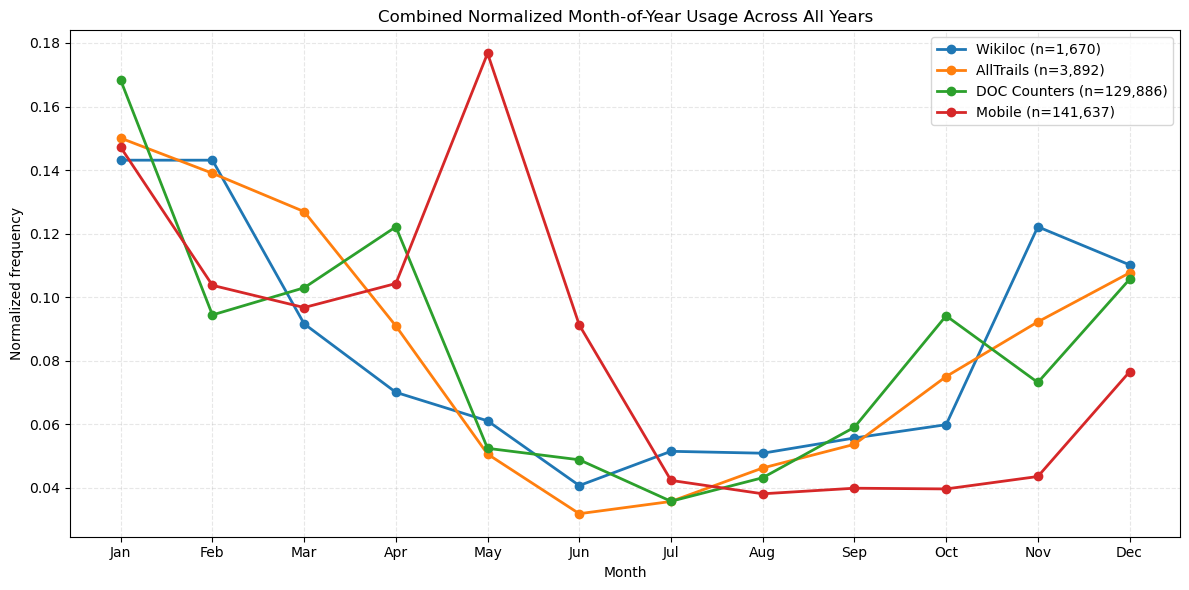

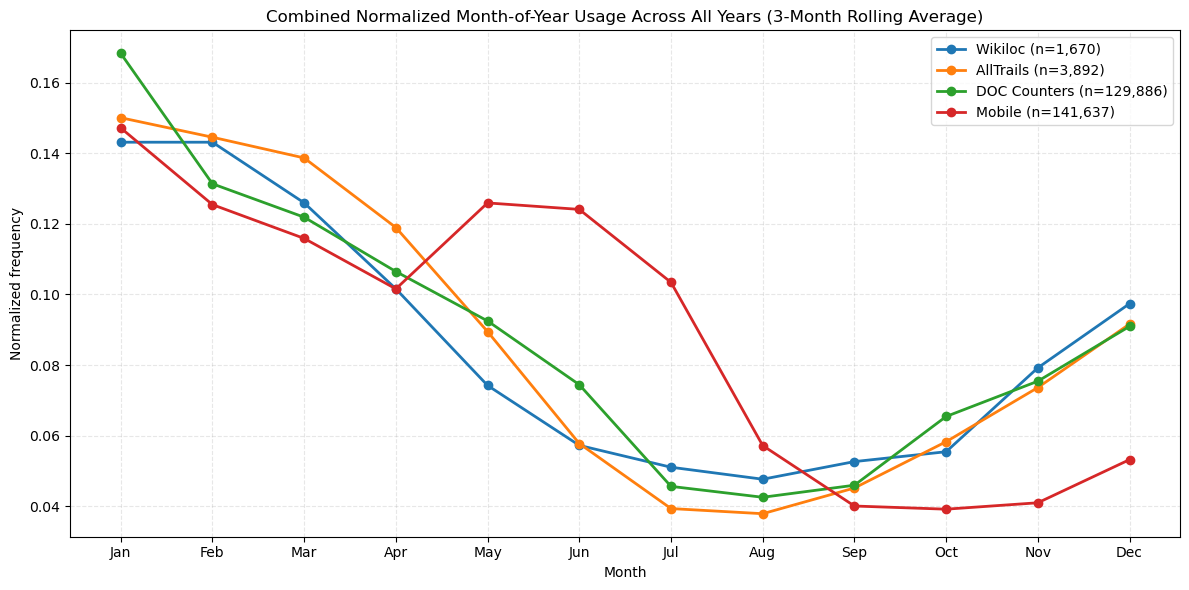

In [19]:
# Plot 5: Aggregate all years into a single normalized Jan-Dec profile
# Example: all January observations from all years are summed into January.

month_numbers = pd.Index(range(1, 13), name="month")
month_labels = [pd.Timestamp(2000, month, 1).strftime("%b") for month in month_numbers]

# Rebuild all-years monthly series directly from cleaned dates (do not apply >2021 filter here)
wikiloc_monthly_all_years = pd.Series(1, index=wikiloc_dates).groupby(pd.Grouper(freq="MS")).sum()
alltrails_monthly_all_years = pd.Series(1, index=alltrails_dates).groupby(pd.Grouper(freq="MS")).sum()
doc_monthly_all_years = (
    Counter_data.assign(Datetime=counter_dates)
    .dropna(subset=["Datetime"])
    .set_index("Datetime")["Count"]
    .groupby(pd.Grouper(freq="MS"))
    .sum()
)
mobile_monthly_all_years = pd.Series(1, index=mobile_dates).groupby(pd.Grouper(freq="MS")).sum()

wikiloc_by_month_all_years = (
    wikiloc_monthly_all_years.groupby(wikiloc_monthly_all_years.index.month)
    .sum()
    .reindex(month_numbers, fill_value=0)
)

alltrails_by_month_all_years = (
    alltrails_monthly_all_years.groupby(alltrails_monthly_all_years.index.month)
    .sum()
    .reindex(month_numbers, fill_value=0)
)

doc_by_month_all_years = (
    doc_monthly_all_years.groupby(doc_monthly_all_years.index.month)
    .sum()
    .reindex(month_numbers, fill_value=0)
)

mobile_by_month_all_years = (
    mobile_monthly_all_years.groupby(mobile_monthly_all_years.index.month)
    .sum()
    .reindex(month_numbers, fill_value=0)
)

wikiloc_by_month_norm = normalize_series(wikiloc_by_month_all_years)
alltrails_by_month_norm = normalize_series(alltrails_by_month_all_years)
doc_by_month_norm = normalize_series(doc_by_month_all_years)
mobile_by_month_norm = normalize_series(mobile_by_month_all_years)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(month_labels, wikiloc_by_month_norm.values, marker="o", linewidth=2, label=f"Wikiloc (n={int(wikiloc_by_month_all_years.sum()):,})")
ax.plot(month_labels, alltrails_by_month_norm.values, marker="o", linewidth=2, label=f"AllTrails (n={int(alltrails_by_month_all_years.sum()):,})")
ax.plot(month_labels, doc_by_month_norm.values, marker="o", linewidth=2, label=f"DOC Counters (n={int(doc_by_month_all_years.sum()):,})")
ax.plot(month_labels, mobile_by_month_norm.values, marker="o", linewidth=2, label=f"Mobile (n={int(mobile_by_month_all_years.sum()):,})")

ax.set_title("Combined Normalized Month-of-Year Usage Across All Years")
ax.set_xlabel("Month")
ax.set_ylabel("Normalized frequency")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Plot 6: same combined view with 3-month rolling average
wikiloc_by_month_norm_roll3 = wikiloc_by_month_norm.rolling(window=3, min_periods=1).mean()
alltrails_by_month_norm_roll3 = alltrails_by_month_norm.rolling(window=3, min_periods=1).mean()
doc_by_month_norm_roll3 = doc_by_month_norm.rolling(window=3, min_periods=1).mean()
mobile_by_month_norm_roll3 = mobile_by_month_norm.rolling(window=3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(month_labels, wikiloc_by_month_norm_roll3.values, marker="o", linewidth=2, label=f"Wikiloc (n={int(wikiloc_by_month_all_years.sum()):,})")
ax.plot(month_labels, alltrails_by_month_norm_roll3.values, marker="o", linewidth=2, label=f"AllTrails (n={int(alltrails_by_month_all_years.sum()):,})")
ax.plot(month_labels, doc_by_month_norm_roll3.values, marker="o", linewidth=2, label=f"DOC Counters (n={int(doc_by_month_all_years.sum()):,})")
ax.plot(month_labels, mobile_by_month_norm_roll3.values, marker="o", linewidth=2, label=f"Mobile (n={int(mobile_by_month_all_years.sum()):,})")

ax.set_title("Combined Normalized Month-of-Year Usage Across All Years (3-Month Rolling Average)")
ax.set_xlabel("Month")
ax.set_ylabel("Normalized frequency")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()